In [1]:
!pip install requests squarenet

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace, field
from squarenet import SquareNet


# ═══════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════

@dataclass
class Config:
    N:                int   = 10_000
    D:                int   = 2
    S:                float = 1.0
    expension_factor: float = 0.3
    LR_spatial:       float = 0.1
    LR_spectral:      float = 0.1
    spatial_radius:   int   = 7
    spectral_radius:  int   = 7
    N_STEPS:          int   = 6
    N_PER_STEP:       int   = 10
    ROOT:             bool  = False   # skip hierarchical bootstrap, run directly
    LEAF:             bool  = True    # plot & return final points

    @classmethod
    def auto(cls, N: int, D: int) -> "Config":
        """Return sensible defaults for dimension D."""
        presets = {
            2: dict(spatial_radius=7, spectral_radius=7),
            3: dict(spatial_radius=5, spectral_radius=5),
            4: dict(spatial_radius=4, spectral_radius=4, LR_spatial = 0.01, LR_spectral = 0.01, expension_factor = 1.0, N_STEPS = 12),
            5: dict(spatial_radius=4, spectral_radius=4, LR_spatial = 0.001, LR_spectral = 0.001, expension_factor = 3.0, N_STEPS = 12),
        }
        if D not in presets:
            raise NotImplementedError(f"No preset for D={D}. Define one manually.")
        return cls(N=N, D=D, **presets[D])


# ══════════════════════════════════════════
# Math utilities
# ══════════════════════════════════════════

def integers_in_ball(radius: float, D: int) -> np.ndarray:
    """Integer lattice vectors inside a sphere of given radius (origin excluded)."""
    if radius <= 0.9:
        return np.zeros((0, D), dtype=np.int32)
    if radius <= 1.9:
        return np.eye(D, dtype=np.int32)
    r   = np.arange(-radius, radius + 1)
    pts = np.stack(np.meshgrid(*(r,) * D, indexing="ij"), axis=-1).reshape(-1, D)
    d2  = np.sum(pts ** 2, axis=-1)
    return pts[(d2 > 0) & (d2 <= radius ** 2)]


def simplex(D: int) -> np.ndarray:
    """Vertices of a regular simplex in R^D  (D+1 rows, D columns)."""
    if D == 1:
        return np.array([-1, 1], dtype=float)[:, None]
    null = np.zeros((D, 1))
    tip  = np.zeros((1, D));  tip[0, -1] = 1.0
    base = np.hstack((simplex(D - 1), null))
    return np.vstack((np.sqrt(1 - (1 / D) ** 2) * base - tip / D, tip))


def split(N: int, D: int):
    """Smallest D-cube grid that contains N points."""
    I    = int(np.ceil(N ** (1.0 / D)))
    IJK  = (I,) * D
    Axes = tuple(range(D))
    return IJK, I ** D, Axes


def torus_point(x):
    """Wrap coordinates into [0, 1)^D."""
    return x - jnp.floor(x)


def torus_delta(delta):
    """Shortest signed distance on a unit torus (faster than mod)."""
    return delta - jnp.round(delta)


def clean_grad(x):
    """Replace NaN gradient contributions (fictive points) with 0."""
    return jnp.nan_to_num(x, nan=0.0)


def clean_points(x):
    """Preserve NaN status flag on fictive points after a torus wrap."""
    status = x[..., -1:]
    return x.at[..., -1:].set(jnp.round(status))


def prepare_points(x: np.ndarray | None, N_asked: int, IJK, D: int):
    """
    Pad N_asked real points to fill the I^D grid.
    Extra slots get a NaN status coordinate so gradients ignore them.
    """
    if x is None:
        x = np.random.rand(N_asked, D)
    else:
        x = np.asarray(x).reshape(N_asked, D)

    total  = int(np.prod(IJK))
    xfull  = np.random.rand(total, D + 1)
    xfull[:, -1]        = 0.0          # status = 0  → real
    xfull[:N_asked, :D] = x
    xfull[N_asked:, D]  = np.nan       # status = NaN → fictive
    return jnp.array(xfull.reshape(*IJK, D + 1))


def prepare_wave_vectors(Ks: np.ndarray):
    """Wave-vectors K and their normalised duals K_, padded for the grid layout."""
    _, D = Ks.shape
    K  = 2.0 * jnp.pi * Ks * 1j
    K  = jnp.array(
        jnp.concatenate((K, np.zeros((len(K), 1))), axis=1)[:, None, :]
    )
    Kn = (jnp.abs(K)**2).sum(axis=-1, keepdims=True)
    return K, -K / Kn

def gauss_kernel(x, y, sigma2):
    delta = torus_delta(y - x)
    dist2 = jnp.sum(delta ** 2, axis=-1, keepdims=True)
    return delta * jnp.exp(-dist2 / sigma2)

def gauss_sin_kernel(x, y, a, b, c):
    d      = a * (y - x)
    cos_t  = b * (1.0 - jnp.cos(d))
    dist2  = jnp.sum(cos_t, axis=-1, keepdims=True)
    return c * jnp.sin(d) * jnp.exp(-dist2)

# ══════════════════════════════════════════
# Small-N bootstrap  (direct gradient descent, O(N²) but simple)
# ══════════════════════════════════════════

def _bootstrap_pipeline(N: int, D: int):
    """
    Build and AOT-compile a gradient-descent sampler for N ≤ ~3 000 points.
    Returns a callable  sample(init=None) → jnp.array  (N, D).
    """
    DX     = 1.0 / N ** (1.0 / D)
    S      = 1.0
    sigma2 = S * 2.0 * DX ** 2
    high_D = sigma2 >= 0.03

    lr_table = {2: 0.4, 3: 0.1, 4: 0.05, 5: 0.02}
    lr    = lr_table.get(D, 0.01)
    Niter = 1_000 if high_D else 3_000

    if high_D:
        a = 2.0 * jnp.pi
        b = 2.0 / (sigma2 * a ** 2)
        c = 1.0 / (2.0 * S * jnp.pi)
        print(f"[bootstrap] kernel=gaussian_sine  σ²={sigma2:.4f}")

        def kernel(x, y):
            return gauss_sin_kernel(x, y, a, b, c)

    else:
        print(f"[bootstrap] kernel=gaussian       σ²={sigma2:.4f}")

        def kernel(x, y):
            return gauss_kernel(x, y, sigma2)

    def grad(x):
        return kernel(x[:, None], x[None, :]).sum(axis=1)

    @jax.jit
    def run(x):
        def step(_, x):
            return torus_point(x - lr * grad(x))
        return jax.lax.fori_loop(0, Niter, step, x)

    print("[bootstrap] compiling…")
    compiled = run.lower(jax.ShapeDtypeStruct((N, D), jnp.float32)).compile()
    print("[bootstrap] ready.")

    def sample(init=None):
        if init is None:
            init = np.random.rand(N, D)
        out = compiled(jnp.asarray(init))
        out.block_until_ready()
        return out

    return sample


# ══════════════════════════════════════════
# Main optimisation pipeline
# ══════════════════════════════════════════

def run(cfg: Config = Config(), x: np.ndarray | None = None) -> np.ndarray:
    """
    Generate a stealthy point pattern according to *cfg*.

    Parameters
    ----------
    cfg : Config
        Algorithm hyper-parameters (use Config.auto(N, D) for defaults).
    x   : array (N, D) | None
        Optional warm start. Forces ROOT=True when provided.

    Returns
    -------
    points : np.ndarray  (N, D)
    """
    N_asked = cfg.N
    D       = cfg.D
    IJK, N_grid, Axes = split(N_asked, D)
    Nsqrt  = N_asked ** (1.0 / 2.0)
    Ncbrt   = N_asked ** (1.0 / D)

    N_STEPS    = cfg.N_STEPS
    N_PER_STEP = cfg.N_PER_STEP
    LEAF       = cfg.LEAF

    is_root = cfg.ROOT or (N_asked <= 1_000) or (x is not None)
    cfg     = replace(cfg, ROOT=is_root)

    # ── Pre-compute constants ───────────────────────────────────────────
    S      = cfg.S
    sigma2 = S * 2.0 * (1.0 / Ncbrt) ** 2

    SHIFTS        = integers_in_ball(cfg.spatial_radius,  D)
    Ks            = integers_in_ball(cfg.spectral_radius, D)
    Ks = Ks[Ks[:, 0] >= 0] #drop half of the wavevectors (symetrie)
    K_w, K_       = prepare_wave_vectors(Ks)
    Clone_simplex = jnp.array(simplex(D))
    expension_factor = cfg.expension_factor

    high_D = sigma2 >= 0.03

    # ── Gradient components ─────────────────────────────────
    if high_D:
        a = 2.0 * jnp.pi
        b = 2.0 / (sigma2 * a ** 2)
        c = 1.0 / (2.0 * S * jnp.pi)
        def micro_kernel(x, y):
            return gauss_sin_kernel(x, y, a, b, c)

    else:
        def micro_kernel(x, y):
            return gauss_kernel(x, y, sigma2)


    def micro_grad(x):
        def body(acc, shift):
            acc = acc + clean_grad(micro_kernel(x, jnp.roll(x, shift, axis=Axes)))
            return acc, None
        out, _ = jax.lax.scan(body, jnp.zeros_like(x), SHIFTS)
        return (cfg.LR_spatial / S) * out

    def macro_kernel(x, K_w, K_):
        x_flat = x.reshape(-1, D + 1)
        def body(acc, args):
            k, k_ = args
            phase = jnp.sum(k * x_flat, axis=-1, keepdims=True)
            ek = clean_grad(jnp.exp(phase))
            Sk = jnp.sum(ek, axis=0, keepdims=True)
            contrib = jnp.real(Sk * k_ * jnp.conjugate(ek))
            acc = acc + contrib
            return acc, None

        init = jnp.zeros_like(x_flat)
        out, _ = jax.lax.scan(body, init, (K_w[:, 0], K_[:, 0]))
        return out.reshape(*IJK, D + 1)

    def macro_grad(x):
        return (cfg.LR_spectral / (Nsqrt*Ncbrt)) * macro_kernel(x, K_w, K_)

    # ── Grid assignment (SquareNet, called via JAX callback) ─────────────────
    sn   = SquareNet(gridshape=IJK, max_iter=50, verbose=0)
    def gridify(x):
        flat = torus_point(np.random.permutation(np.array(x.reshape(-1, D + 1))) - 0.5)
        sn.fit(flat[:, :D], method="ultimate")
        return jnp.asarray(sn.map(flat))

    def cb_gridify(x):
        return jax.pure_callback(gridify, jax.ShapeDtypeStruct(x.shape, x.dtype), x)

    # ── Clone: expand N//(D+1) parents into N children ─────────────────
    def clone(x: np.ndarray) -> np.ndarray:
        x         = x.reshape(-1, D + 1)
        x         = x[np.isfinite(x[:, -1]), :D]
        x         = np.random.permutation(x)
        N_parents = N_asked // (D + 1)
        N_keep    = N_asked - (D + 1) * N_parents
        Q, _      = np.linalg.qr(np.random.randn(N_parents, D, D))
        offsets   = np.einsum("nij,kj->nki", Q, np.array(Clone_simplex)) * (expension_factor / Ncbrt)
        children  = (x[:N_parents, None, :] + offsets).reshape(-1, D)
        if N_keep > 0:
            children = np.concatenate([x[N_parents:], children], axis=0)
        return torus_point(children)

    # ── JIT-compiled inner loop ────────────────────────
    @jax.jit
    def run_steps(x):
        def step(i, x):
            x = jax.lax.cond(i % N_PER_STEP == 0, cb_gridify, lambda x: x, x)
            return clean_points(torus_point(x - micro_grad(x)- macro_grad(x)))
        return jax.lax.fori_loop(0, N_STEPS * N_PER_STEP, step, x)

    # ── Hierarchical bootstrap or direct init ────────────────────
    if cfg.ROOT:
        seed = _bootstrap_pipeline(N_asked, D)(x)
        x    = prepare_points(seed, N_asked, IJK, D)
    else:
        child_cfg = replace(cfg, N=N_asked // (D + 1) + N_asked % (D + 1), LEAF=False)
        seed      = clone(run(child_cfg))
        plot(seed)
        x = prepare_points(seed, N_asked, IJK, D)
        print(cfg)
        x = run_steps(x)

    if LEAF:
        x = np.array(x.reshape(-1, D + 1))
        x = x[np.isfinite(x[:, -1]), :D]
        plot(x)

    return x


# ══════════════════════════════════════════
# Visualisation
# ══════════════════════════════════════════

def plot(points, max_scatter: int = 30_000) -> None:
    """Scatter plot of a 2D or 3D point set (auto-zooms if N > max_scatter)."""
    pts = np.asarray(points).reshape(-1, points.shape[-1])
    D   = min(pts.shape[-1], 3)
    pts = pts[:, :D]

    if len(pts) > max_scatter:
        zoom = (max_scatter / len(pts)) ** (1.0 / D)
        pts  = pts[(pts <= zoom).all(axis=1)]

    fig = plt.figure(figsize=(8, 8))
    if D == 2:
        ax = fig.add_subplot(111)
        ax.scatter(pts[:, 0], pts[:, 1], s=0.4, color="black")
    else:
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.4, color="black")

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


def plot_structure_factor(x: np.ndarray, bins: int = 100, resolution: float = 30.0) -> None:
    """Log-log plot of the radial structure factor S(k)."""
    k, S = structure_factor(x.reshape(-1, x.shape[-1]), nbins=bins, resolution=resolution)
    plt.figure()
    plt.loglog(k, S, marker="o", markersize=2, linewidth=1)
    plt.xlabel("k");  plt.ylabel("S(k)")
    plt.title("Structure factor  (log-log)")
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()


def structure_factor(points: np.ndarray, nbins: int = 100, resolution: float = 30.0):
    """
    Estimate the radial structure factor via scattering intensity.

    Returns
    -------
    k : np.ndarray  – bin centres
    S : np.ndarray  – mean S(k) per bin
    """
    pts = np.asarray(points)
    N, D = pts.shape

    kmed = int(1_000 ** (1.0 / D))
    kmax = int(2 * N ** (1.0 / D))
    bins = np.linspace(0, kmax, nbins)

    # Wave-vector sampling
    nvecs = np.random.randint(-kmax, kmax + 1, size=(int(resolution * nbins), D))
    nvecs = np.concatenate([nvecs, integers_in_ball(kmed, D)], axis=0)
    nvecs = nvecs[np.any(nvecs != 0, axis=1)]

    knorm   = np.linalg.norm(nvecs, axis=1)
    bin_idx = np.searchsorted(bins, knorm) - 1
    valid   = (bin_idx >= 0) & (bin_idx < len(bins) - 1)
    nvecs, bin_idx = nvecs[valid], bin_idx[valid]

    kvecs = jnp.array(2.0 * np.pi * nvecs)
    pts_j = jnp.array(pts)

    def Sk_one(k):
        rho = jnp.sum(jnp.exp(1j * (pts_j @ k)), axis=0)
        return jnp.abs(rho) ** 2 / N

    Sk = np.asarray(jax.lax.map(Sk_one, kvecs))

    n_bins = len(bins) - 1
    S_sum  = np.bincount(bin_idx, weights=Sk, minlength=n_bins)
    counts = np.bincount(bin_idx,             minlength=n_bins)

    S = np.zeros_like(S_sum, dtype=float)
    valid_indices = counts > 0
    S[valid_indices] = S_sum[valid_indices] / counts[valid_indices]

    mask   = counts > 0
    return (0.5 * (bins[:-1] + bins[1:]))[mask], S[mask]


# ══════════════════════════════════════════
# Entry points
# ══════════════════════════════════════════
if False:
    if __name__ == "__main__":
        # ── Quick 2D test (ROOT forces the small-N bootstrap) ─────────────────────
        cfg = Config.auto(N=1_000, D=2)
        cfg = replace(cfg, ROOT=True)
        x   = run(cfg)
        plot_structure_factor(x)
        print("shape:", x.shape)

        # ── Full hierarchical 3D run, 10 000 points ───────────────────────
        x = run(Config(N=10_000, D=3))
        plot_structure_factor(x)

        # ── Large 2D run, 100 000 points ────────────────────
        # NOTE: 3D at this scale is ~5× slower (≈ 50 min for 1 M points)
        x = run(Config.auto(N=100_000, D=2))
        plot_structure_factor(x)


[bootstrap] kernel=gaussian       σ²=0.0032
[bootstrap] compiling…
[bootstrap] ready.


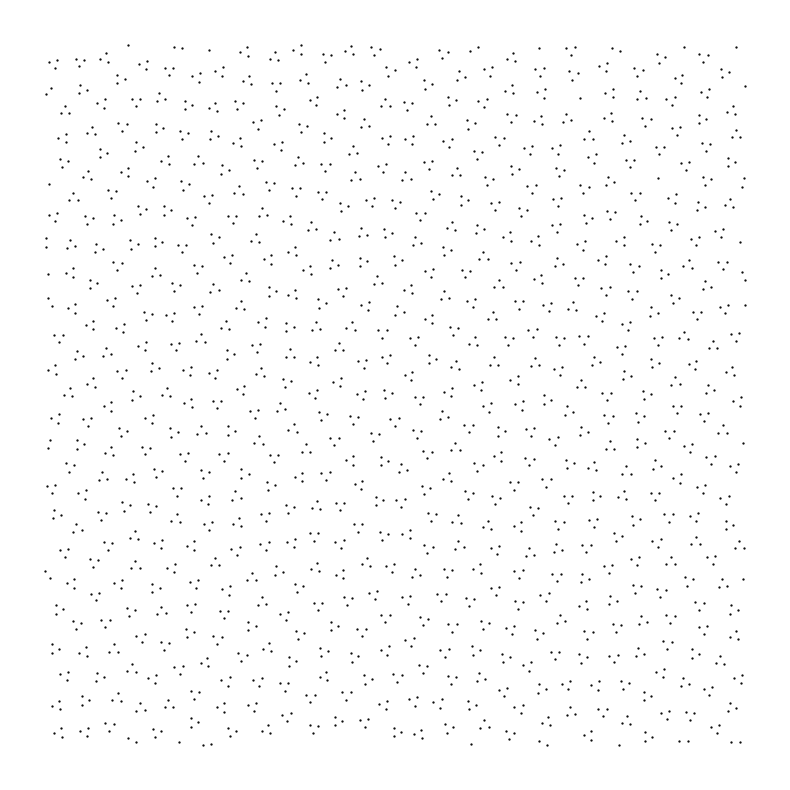

Config(N=1853, D=2, S=1.0, expension_factor=0.3, LR_spatial=0.1, LR_spectral=0.1, spatial_radius=7, spectral_radius=7, N_STEPS=6, N_PER_STEP=10, ROOT=False, LEAF=False)


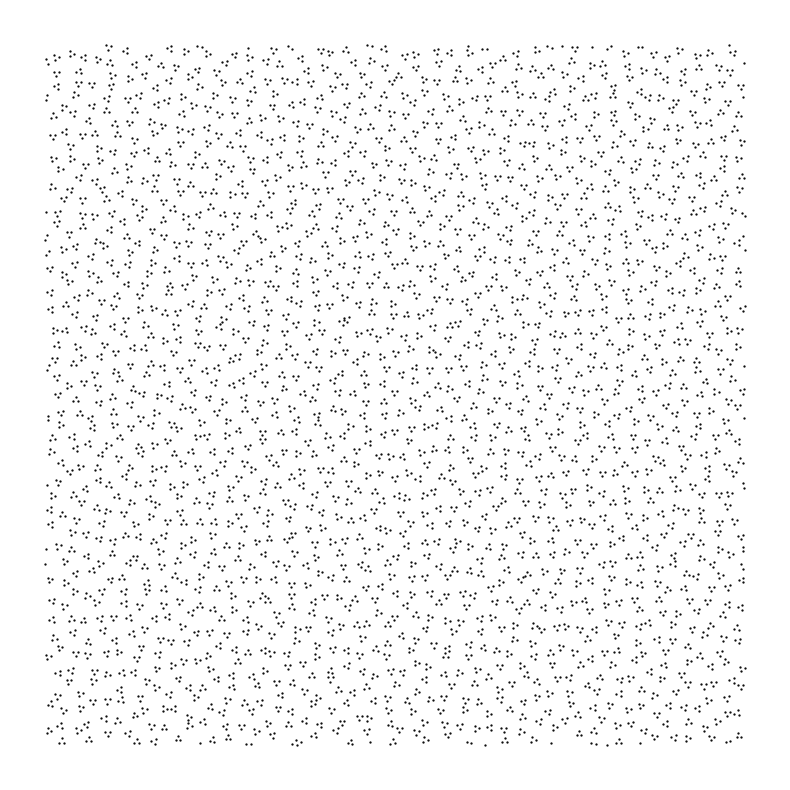

Config(N=5557, D=2, S=1.0, expension_factor=0.3, LR_spatial=0.1, LR_spectral=0.1, spatial_radius=7, spectral_radius=7, N_STEPS=6, N_PER_STEP=10, ROOT=False, LEAF=False)


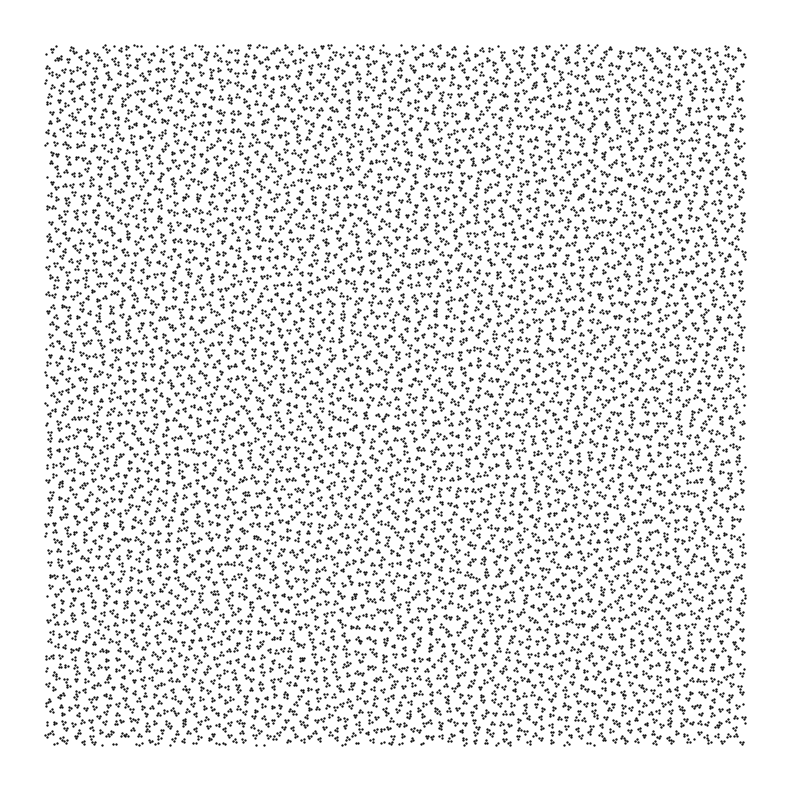

Config(N=16667, D=2, S=1.0, expension_factor=0.3, LR_spatial=0.1, LR_spectral=0.1, spatial_radius=7, spectral_radius=7, N_STEPS=6, N_PER_STEP=10, ROOT=False, LEAF=False)


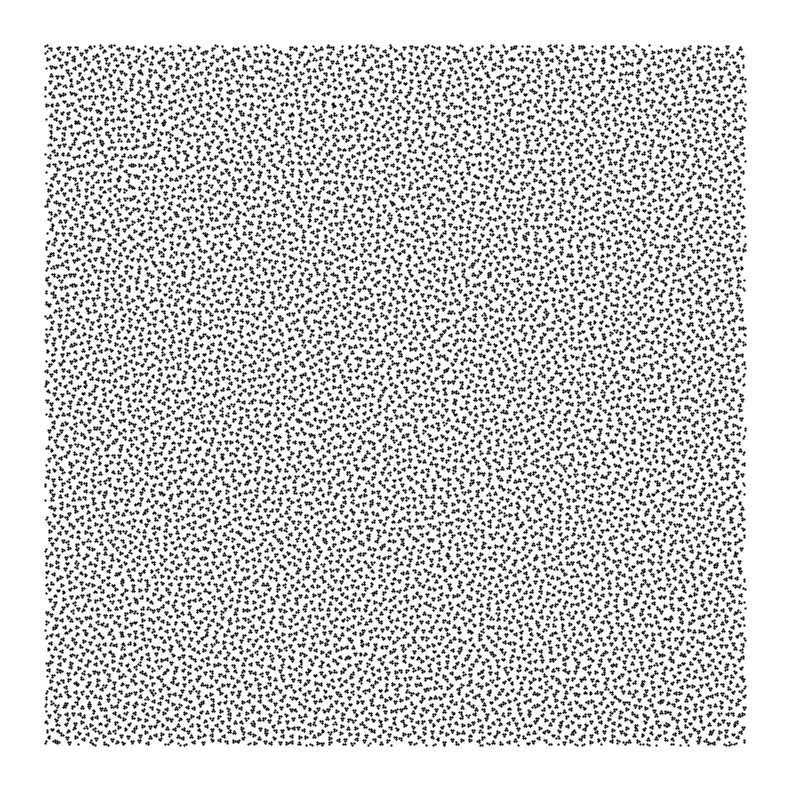

Config(N=50001, D=2, S=1.0, expension_factor=0.3, LR_spatial=0.1, LR_spectral=0.1, spatial_radius=7, spectral_radius=7, N_STEPS=6, N_PER_STEP=10, ROOT=False, LEAF=True)


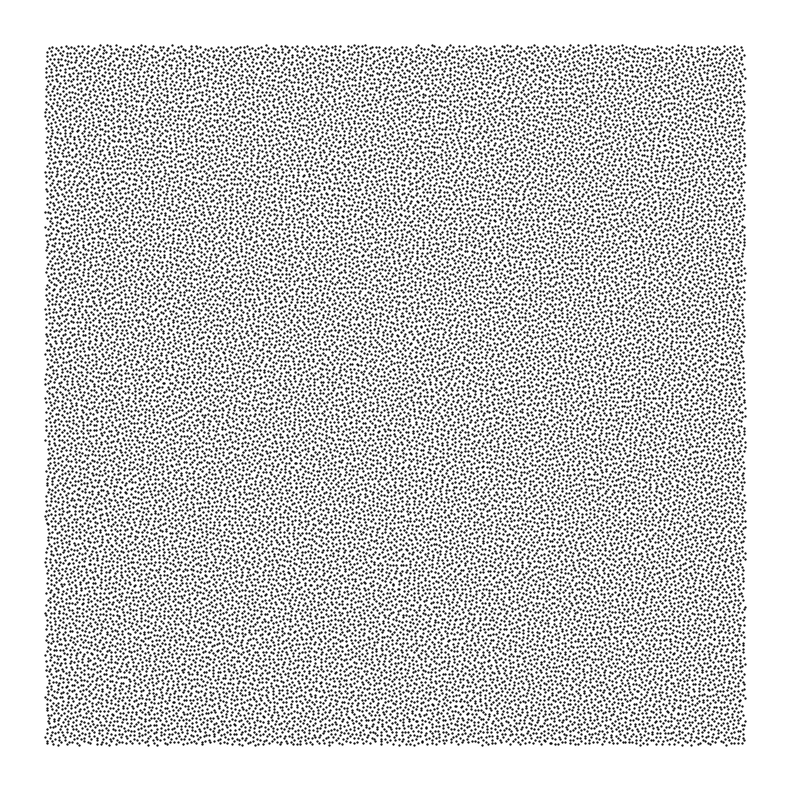

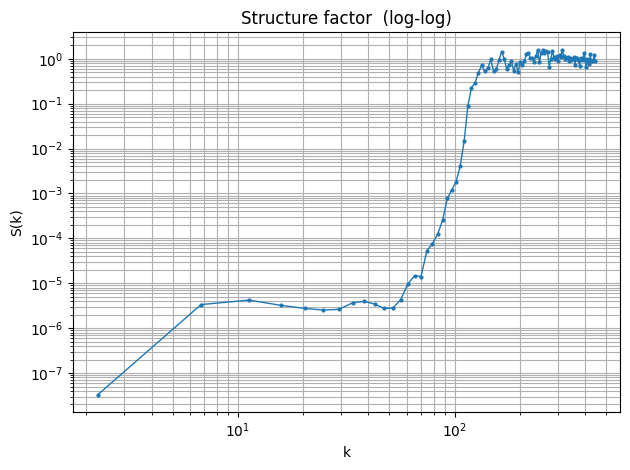

In [3]:
cfg = Config.auto(N=50_001, D=2)
x = run(cfg)
plot_structure_factor(x)